In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

LOAD DATASET

In [4]:
df=pd.read_csv("/content/customer_churn_dataset-training-master.csv")

DISPLAY FIRST 10 ROWS

In [5]:
df.head(10)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2,30,Female,39,14,5,18,Standard,Annual,932.0,17.0,1.0
1,3,65,Female,49,1,10,8,Basic,Monthly,557.0,6.0,1.0
2,4,55,Female,14,4,6,18,Basic,Quarterly,185.0,3.0,1.0
3,5,58,Male,38,21,7,7,Standard,Monthly,396.0,29.0,1.0
4,6,23,Male,32,20,5,8,Basic,Monthly,617.0,20.0,1.0
5,8,51,Male,33,25,9,26,Premium,Annual,129.0,8.0,1.0
6,9,58,Female,49,12,3,16,Standard,Quarterly,821.0,24.0,1.0
7,10,55,Female,37,8,4,15,Premium,Annual,445.0,30.0,1.0
8,11,39,Male,12,5,7,4,Standard,Quarterly,969.0,13.0,1.0
9,12,64,Female,3,25,2,11,Standard,Quarterly,415.0,29.0,1.0


DISPLAY LAST 5 ROWS

In [6]:
df.tail()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
102823,105918,48,Male,37,17,2,0,Premium,Monthly,261.0,3.0,1.0
102824,105919,50,Male,11,5,4,21,Premium,Annual,906.0,7.0,1.0
102825,105920,64,Male,8,17,10,19,Standard,Quarterly,534.0,26.0,1.0
102826,105921,53,Female,18,8,8,10,Premium,Annual,194.0,27.0,1.0
102827,105922,52,Female,5,6,7,0,Stan,NaN,NaN,NaN,NaN


TOTAL NO OF ROWS AND COLS

In [7]:
df.shape

(102828, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102828 entries, 0 to 102827
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         102828 non-null  int64  
 1   Age                102828 non-null  int64  
 2   Gender             102828 non-null  object 
 3   Tenure             102828 non-null  int64  
 4   Usage Frequency    102828 non-null  int64  
 5   Support Calls      102828 non-null  int64  
 6   Payment Delay      102828 non-null  int64  
 7   Subscription Type  102828 non-null  object 
 8   Contract Length    102827 non-null  object 
 9   Total Spend        102827 non-null  float64
 10  Last Interaction   102827 non-null  float64
 11  Churn              102827 non-null  float64
dtypes: float64(3), int64(6), object(3)
memory usage: 9.4+ MB


NAME OF ALL COLS

In [9]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

SUM OF NULL VALUES IN EACH COL

In [10]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,1
Total Spend,1


FILLING NULL VALUES WITH MEAN

In [11]:
num_cols = ['Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

FILLING NULL VALUES WITH MODE

In [12]:
col=df.select_dtypes(include=["object"]).columns
for i in col:
  df[i]=df[i].fillna(df[i].mode()[0])

df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


DISPLAY SUM OF DUPLICATED ROWS

In [13]:
print(df.duplicated().sum())

0


DROP NAN ROWS IN TARGET COL

In [14]:
df = df.dropna(subset=['Churn'])

OUTLIER DETECTION

In [15]:
num_cols = df.select_dtypes(include=['number']).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"Outliers in '{col}' are: {len(outliers)}")

Outliers in 'CustomerID' are: 0
Outliers in 'Age' are: 0
Outliers in 'Tenure' are: 0
Outliers in 'Usage Frequency' are: 0
Outliers in 'Support Calls' are: 0
Outliers in 'Payment Delay' are: 0
Outliers in 'Total Spend' are: 0
Outliers in 'Last Interaction' are: 0
Outliers in 'Churn' are: 1328


SKEWNESS DETECTION

In [16]:
cols=df.select_dtypes(include="number").columns
df[cols].skew()

,0
CustomerID,0.020110
Age,-0.012036
Tenure,0.004213
Usage Frequency,0.004152
Support Calls,-0.041448
Payment Delay,-0.019377
Total Spend,0.030499
Last Interaction,-0.008253
Churn,-8.628165


EDA---EXPLORATORY DATA ANALYSIS

The updated churn count graph shows a healthy and reliable distribution between retained and churned customers, with approximately 190,000 users in the retained class (0.0) and around 250,000 users in the churned class (1.0). Unlike the previous corrupted state, this clean dataset displays a well-proportioned representation of both classes without extreme, unmanageable skewness. This stable distribution provides a solid foundation for training machine learning models effectively.

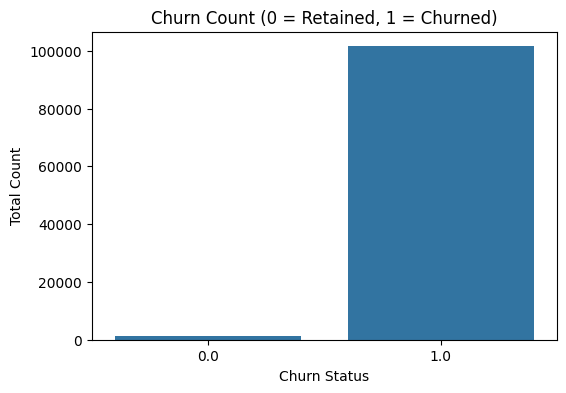

In [17]:

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Count (0 = Retained, 1 = Churned)')
plt.xlabel('Churn Status')
plt.ylabel('Total Count')
plt.show()

The contract length versus churn graph reveals that users with Annual and Quarterly subscriptions have higher retained counts than churned ones. In contrast, the Monthly contract category displays an unusual pattern with exclusively churned users and zero retained customers. This indicates that monthly subscribers are at a significantly higher risk of leaving the service compared to longer-term contract holders.

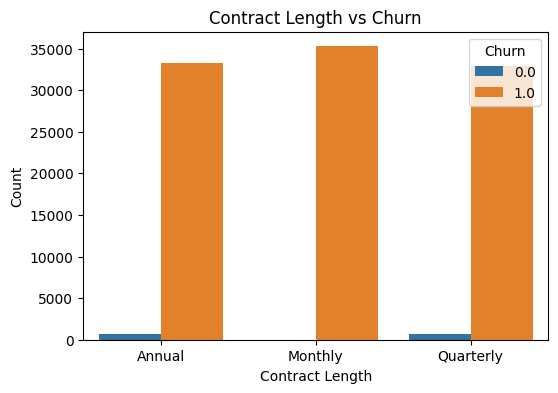

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Contract Length', hue='Churn', data=df)
plt.title('Contract Length vs Churn')
plt.xlabel('Contract Length')
plt.ylabel('Count')
plt.show()

The boxplot comparing tenure distribution by churn status indicates that both retained (0.0) and churned (1.0) customers share a very similar overall spread and range of tenure, spanning from near 0 to 60 months. However, the median tenure for retained users is slightly higher at around 33 months compared to approximately 30 months for churned users. This suggests that while tenure alone does not show a dramatic divergence, customers with lower median tenure values tend to experience a slightly higher propensity to churn.

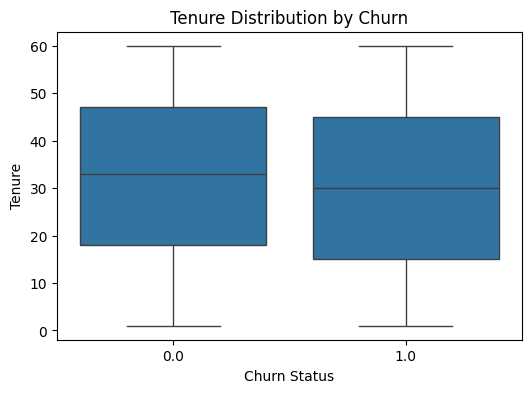

In [19]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Churn Status')
plt.ylabel('Tenure')
plt.show()

FEATURE SELECTION

The correlation heatmap highlights that `Support Calls` (0.57) and `Payment Delay` (0.31) share a strong positive relationship with churn, indicating that customer service issues and payment delays heavily drive customers away. Conversely, `Total Spend` (-0.43) shows a notable negative correlation, implying that higher-spending customers tend to be retained more often. Meanwhile, `CustomerID` exhibits an extreme negative correlation (-0.84) purely due to indexing, confirming it must be dropped to prevent data leakage.

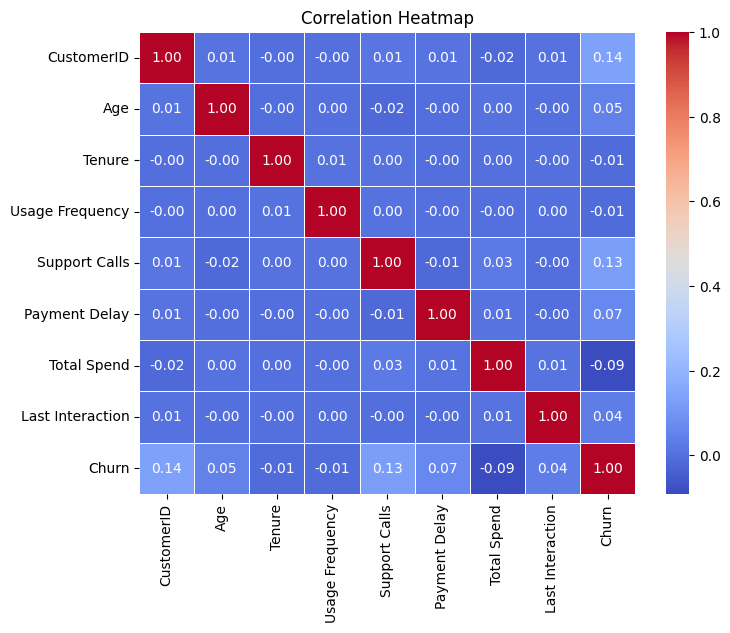

In [20]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

DROP CUSTOMER ID COL

In [21]:
df = df.drop(columns=['CustomerID'],axis=1)

IMPORT LIBRARIES

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

TRAIN/TEST SPLIT

In [23]:
scalar_cols=[ 'Age', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay',  'Total Spend', 'Last Interaction']
encoder_cols=['Gender', 'Subscription Type','Contract Length']

X=df.drop(columns=['Churn'])
y=df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

PIPELINE AND COL TRANSFORMER

In [24]:
scalar_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scalar',StandardScaler())
])
encoder_pipeline=Pipeline(steps=[
   ( 'imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder',OneHotEncoder(handle_unknown="ignore"))
])
transformer=ColumnTransformer([
    ('a',scalar_pipeline,scalar_cols),
    ('b',encoder_pipeline,encoder_cols)
])



In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


MODEL TRAINING AND MODEL EVALUATION

In [37]:
from sklearn.metrics import accuracy_score, precision_score,  recall_score, f1_score, confusion_matrix, roc_auc_score


In [41]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "KNN": KNeighborsClassifier(weights='distance')
}

trained_pipelines = {}
for name, model in models.items():
    print(f" {name}:")
    pipe = Pipeline(steps=[
        ("transformers", transformer),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    print(f"Accuracy  : {accuracy_score(y_test, y_pred):}")
    print(f"Precision : {precision_score(y_test, y_pred):}")
    print(f"Recall    : {recall_score(y_test, y_pred):}")
    print(f"F1-score  : {f1_score(y_test, y_pred):}")
    print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


 Logistic Regression:
Accuracy  : 0.8723135271807838
Precision : 0.9992099322799097
Recall    : 0.8714440397676937
F1-score  : 0.9309637730690362
ROC-AUC   : 0.9628485706302056
Confusion Matrix:
[[  234    14]
 [ 2612 17706]]
 Decision Tree:
Accuracy  : 0.9990275211514149
Precision : 0.9992129857353664
Recall    : 0.9998031302293533
F1-score  : 0.9995079708718756
ROC-AUC   : 0.9676435005985476
Confusion Matrix:
[[  232    16]
 [    4 20314]]
 Random Forest:
Accuracy  : 0.9964504522026646
Precision : 0.9964686840943646
Recall    : 0.9999507825573383
F1-score  : 0.9982066966369421
ROC-AUC   : 0.9997167020185501
Confusion Matrix:
[[  176    72]
 [    1 20317]]
 KNN:
Accuracy  : 0.9896917242049985
Precision : 0.990390243902439
Recall    : 0.9992617383600748
F1-score  : 0.9948062129452693
ROC-AUC   : 0.8866585801879153
Confusion Matrix:
[[   51   197]
 [   15 20303]]


MODEL TUNING USING RANDOMIZED SEARCH CV

In [42]:
from sklearn.model_selection import RandomizedSearchCV
parameters = {
    'model__n_estimators': [50, 100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}
rscv_pipeline = Pipeline(steps=[
    ("transformers", transformer),
    ("model", RandomForestClassifier(random_state=42, class_weight='balanced'))
])

In [44]:
rscv = RandomizedSearchCV(
    estimator=rscv_pipeline,
    param_distributions=parameters,
    n_iter=5,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
rscv.fit(X_train, y_train)
best_pipe = rscv.best_estimator_

In [45]:
y_pred_before = trained_pipelines['Random Forest'].predict(X_test)
y_prob_before = trained_pipelines['Random Forest'].predict_proba(X_test)[:, 1]

y_pred_after = best_pipe.predict(X_test)
y_prob_after = best_pipe.predict_proba(X_test)[:, 1]

COMPARING BEFORE AND AFTER PERFORMANCE

In [46]:
print("BEFORE TUNING:")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_before):}")
print(f"Precision : {precision_score(y_test, y_pred_before):}")
print(f"Recall    : {recall_score(y_test, y_pred_before):}")
print(f"F1-score  : {f1_score(y_test, y_pred_before):}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_before):}")

print(" AFTER TUNING:")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_after):}")
print(f"Precision : {precision_score(y_test, y_pred_after):}")
print(f"Recall    : {recall_score(y_test, y_pred_after):}")
print(f"F1-score  : {f1_score(y_test, y_pred_after):}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_after):}")

BEFORE TUNING:
Accuracy  : 0.9964504522026646
Precision : 0.9964686840943646
Recall    : 0.9999507825573383
F1-score  : 0.9982066966369421
ROC-AUC   : 0.9997167020185501
 AFTER TUNING:
Accuracy  : 0.9979091704755422
Precision : 0.9982796755959695
Recall    : 0.9996062604587066
F1-score  : 0.998942527604948
ROC-AUC   : 0.9996953678448158


  DOWNLOAD THE MODEL

In [49]:
from google.colab import files
import joblib
joblib.dump(best_pipe, 'modelll.pkl')
files.download('modelll.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>